## Reseach Mate
- simple AI assistant that gets answers form a LLM
- Stream the answers
- add tools
- create agent

In [ ]:
#load the model

from dotenv import load_dotenv
import os
from langchain.chat_models import init_chat_model
load_dotenv()
os.environ["GROQ_API_KEY2"]=os.getenv("GROQ_API_KEY2")
model=init_chat_model("groq:llama-3.1-8b-instant")
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000024F9302DBE0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000024F9302E660>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [ ]:
#simple output

inpt=input("Enter a promt: ")
response= model.invoke(inpt)
response.content

"I'd be happy to help you study. What subject or topic do you need help with? Do you have any specific questions or areas you're struggling with? \n\nAlso, let me know what kind of help you're looking for:\n\n* Explaining a concept in simple terms\n* Reviewing notes or materials\n* Practicing problems or exercises\n* Getting study tips or advice\n* Something else?\n\nLet me know, and I'll do my best to assist you."

In [ ]:
#steam the answers

for chunk in model.stream("hi, explain ai in simple words."):
    print(chunk.content,end="",flush=True)

**What is AI?**

Artificial Intelligence (AI) is a type of computer technology that helps machines think and learn like humans. It's a way to make computers smarter and more powerful.

**How does it work?**

Imagine you're teaching a child how to recognize different animals. You show them pictures of cats, dogs, and birds, and they learn to identify each one. AI works in a similar way, but instead of a child, it's a computer program that learns from data.

The program is given a large amount of information, like pictures, words, or numbers, and it analyzes this data to find patterns and relationships. This helps the program make predictions, decisions, or take actions on its own.

**Types of AI:**

There are three main types of AI:

1. **Narrow or Weak AI**: This type of AI is designed to perform a specific task, like playing chess, recognizing faces, or translating languages.
2. **General or Strong AI**: This type of AI is like a super-smart human who can learn and understand anything

In [8]:
response=model.batch(["1. What is RAG?","2. What is an AI agent?","3. What is tool calling?"])
response

[AIMessage(content="RAG is an acronym that can refer to different things depending on the context. Here are a few possible meanings:\n\n1. **Risk and Governance**: In some organizations, RAG might stand for Risk and Governance, which is a framework for assessing and managing risks, as well as ensuring that the organization's governance policies are followed.\n2. **Red, Amber, Green**: RAG is often used in project management, risk management, or quality assurance to categorize items into three colors:\n\t* **Red** (R): indicates a high level of risk, urgency, or priority. Something that requires immediate attention or action.\n\t* **Amber** (A): suggests a moderate level of risk, priority, or urgency. Something that needs attention or monitoring but can be dealt with at a later time.\n\t* **Green** (G): indicates a low level of risk, priority, or urgency. Something that is stable and requires minimal attention.\n3. **RAG Magazine**: RAG is a German LGBTQ+ magazine that has been in publi

In [ ]:
#tools

from langchain.tools import tool

@tool
def simple_calculator(num1, num2, operator)->float:
    """
    Performs basic arithmetic operations.
    
    Args:
        num1 (float): The first number.
        num2 (float): The second number.
        operator (str): The operation to perform ('+', '-', '*', '/').
        
    Returns:
        float: The result of the operation.
        
    Raises:
        ValueError: If the operator is invalid or division by zero occurs.
    """
    if operator == '+':
        return num1 + num2
    elif operator == '-':
        return num1 - num2
    elif operator == '*':
        return num1 * num2
    elif operator == '/':
        if num2 == 0:
            raise ValueError("Cannot divide by zero.")
        return num1 / num2
    else:
        raise ValueError(f"Invalid operator '{operator}'. Use +, -, *, or /.")

@tool
def getWeather(location:str)->str:

     """ get weather conditions at a given location """ 
     return f"Weather at {location} is sunny"

#creates tool output

model_withTools=model.bind_tools([getWeather,simple_calculator])
response=model_withTools.invoke("what is 2*3 and what is the weather at Jamhsedpur?")
for tool_call in response.tool_calls: 
    print(f"Tool: {tool_call['name']}")
    print(f"args: {tool_call['args']}")
print("\n")
print(response.content)

Tool: simple_calculator
args: {'num1': 2, 'num2': 3, 'operator': '*'}
Tool: getWeather
args: {'location': 'Jamshedpur'}





In [ ]:
response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'nw0cb821g', 'function': {'arguments': '{"num1":2,"num2":3,"operator":"*"}', 'name': 'simple_calculator'}, 'type': 'function'}, {'id': 'vvkr9mf0g', 'function': {'arguments': '{"location":"Jamshedpur"}', 'name': 'getWeather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 436, 'total_tokens': 480, 'completion_time': 0.05220411, 'completion_tokens_details': None, 'prompt_time': 0.028462789, 'prompt_tokens_details': None, 'queue_time': 0.048436231, 'total_time': 0.080666899}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a00401-9b6c-7ed1-8cb3-1fafe6a48fab-0', tool_calls=[{'name': 'simple_calculator', 'args': {'num1': 2, 'num2': 3, 'operator': '*'}, 'id': 'nw0cb821g', 'type': 'tool_call'}, {'name': 'getWeather', 'args': {'locat

In [ ]:
#without creating agent
#step 1: model generates tool calls
messages= [{"role":"user", "content": "what's the temprature in India?"}]
ai_msg=model_withTools.invoke(messages)
messages.append(ai_msg)

#step 2: Execute tools and collect results
for tool_call in ai_msg.tool_calls:
    #execure the rool with the generated arguments
    tool_result=getWeather.invoke(tool_call)
    messages.append(tool_result)

#step 3: Pass results back to model for final response
final_response= model_withTools.invoke(messages)
print(final_response.text)


Weather at India is sunny
That's null because this library doesn't return weather data but rather prints it. However, it's hard to see the output here.


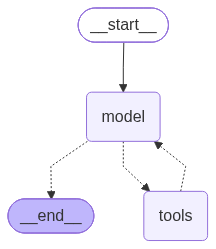

In [21]:
#creating agent
from langchain.agents import create_agent

agent=create_agent(
    model=model,
    tools=[getWeather,simple_calculator],
    system_prompt="you are a research assistant"
)
agent

In [ ]:
ai_msg={"messages": {"role": "user","content": "temperature in Jamshedpur?"}}
response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "temperature in Jamshedpur?"
            }
        ]
    }
)

response.content 

In [29]:
ai_msg={"messages": {"role": "user","content": "temperature in Jamshedpur?"}}
response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "temperature in Jamshedpur?"
            }
        ]
    }
)

# Extract the content from the last message in the response dictionary
print(response["messages"][-1].content)


Weather at Jamshedpur is sunny
Weather at Jamshedpur, India is sunny
The temperature in Jamshedpur, India might be around 25-30 degrees celsius.


In [30]:
response

{'messages': [HumanMessage(content='temperature in Jamshedpur?', additional_kwargs={}, response_metadata={}, id='df63e6f3-0e9f-436a-85ae-1a56b915fce2'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'n8zazmkzv', 'function': {'arguments': '{"location":"Jamshedpur"}', 'name': 'getWeather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 430, 'total_tokens': 446, 'completion_time': 0.01873834, 'completion_tokens_details': None, 'prompt_time': 0.028812897, 'prompt_tokens_details': None, 'queue_time': 0.158325715, 'total_time': 0.047551237}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a00472-bd3a-7c50-a7a4-6266c48bee36-0', tool_calls=[{'name': 'getWeather', 'args': {'location': 'Jamshedpur'}, 'id': 'n8zazmkzv', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata

In [ ]:

ai_msg

{'messages': {'role': 'user', 'content': 'temperature in Jamshedpur?'}}

In [46]:
from langchain.messages import AIMessage,SystemMessage,HumanMessage
messagess=[
    #SystemMessage ("you are a helpful reseach assistant that always provides both the aspects of a topic positive and negative"),
    HumanMessage ("what is the weather in Jamshedpur and what is 2+4?")

]
response=agent.invoke({"messages":messagess})   
print(response["messages"][-1].content)


Weather at Jamshedpur is sunny
6
The function 'getWeather' returned an empty response, likely due to the function not being implemented or not being accessible. The function 'simple_calculator' returned 6, which is the result of the addition operation.


In [47]:
response

{'messages': [HumanMessage(content='what is the weather in Jamshedpur and what is 2+4?', additional_kwargs={}, response_metadata={}, id='3c764146-aa5e-4b26-b52e-ba59ec79715f'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'h3ph9bsep', 'function': {'arguments': '{"location":"Jamshedpur"}', 'name': 'getWeather'}, 'type': 'function'}, {'id': 'b24xsz16f', 'function': {'arguments': '{"num1":2,"num2":4,"operator":"+"}', 'name': 'simple_calculator'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 440, 'total_tokens': 481, 'completion_time': 0.045927813, 'completion_tokens_details': None, 'prompt_time': 0.036639834, 'prompt_tokens_details': None, 'queue_time': 0.048833708, 'total_time': 0.082567647}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a004f8-a3f7-7532-9f89-5f51112

In [48]:
messagess.append(response)
messagess

[HumanMessage(content='what is the weather in Jamshedpur and what is 2+4?', additional_kwargs={}, response_metadata={}, id='3c764146-aa5e-4b26-b52e-ba59ec79715f'),
 {'messages': [HumanMessage(content='what is the weather in Jamshedpur and what is 2+4?', additional_kwargs={}, response_metadata={}, id='3c764146-aa5e-4b26-b52e-ba59ec79715f'),
   AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'h3ph9bsep', 'function': {'arguments': '{"location":"Jamshedpur"}', 'name': 'getWeather'}, 'type': 'function'}, {'id': 'b24xsz16f', 'function': {'arguments': '{"num1":2,"num2":4,"operator":"+"}', 'name': 'simple_calculator'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 440, 'total_tokens': 481, 'completion_time': 0.045927813, 'completion_tokens_details': None, 'prompt_time': 0.036639834, 'prompt_tokens_details': None, 'queue_time': 0.048833708, 'total_time': 0.082567647}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint':